In [1]:
import torch

# Create tensors
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.zeros(3, 256, 256)       # blank grayscale image
c = torch.randn(32, 3, 256, 256)   # batch of 32 random RGB images

# Always print shape
print(a.shape)    # torch.Size([3])
print(b.shape)    # torch.Size([3, 256, 256])
print(c.shape)    # torch.Size([32, 3, 256, 256])
print(c.dtype)    # torch.float32

torch.Size([3])
torch.Size([3, 256, 256])
torch.Size([32, 3, 256, 256])
torch.float32


In [3]:
from PIL import Image
import torchvision.transforms as T

# Use any .jpg image from HAM10000 (or any image for now)
img = Image.open(r"C:\Users\ridam\OneDrive\Pictures\Gallery\owner\pics\IMG_20240731_000633.jpg")
print("Original size:", img.size)   # (width, height)

transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),           # converts to [3, 256, 256] and scales to 0-1
])

tensor = transform(img)
print("Tensor shape:", tensor.shape)   # torch.Size([3, 256, 256])
print("Min value:", tensor.min())      # ~0.0
print("Max value:", tensor.max())      # ~1.0

Original size: (4032, 1908)
Tensor shape: torch.Size([3, 256, 256])
Min value: tensor(0.)
Max value: tensor(1.)


In [5]:
import timm

# Load EfficientNetV2 pretrained on ImageNet
model = timm.create_model('tf_efficientnetv2_s', pretrained=True)
model.eval()

# Create a fake batch of 1 image
x = torch.randn(1, 3, 256, 256)

with torch.no_grad():
    output = model(x)

print("Output shape:", output.shape)   # torch.Size([1, 1000])
# 1000 classes = ImageNet classes
# We will change this to 7 classes later

Output shape: torch.Size([1, 1000])


Matplotlib is building the font cache; this may take a moment.


     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


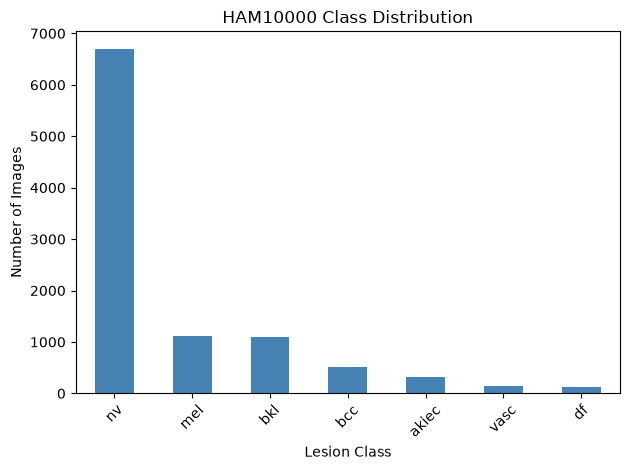


Dumb model accuracy (always predict NV): 66.9%


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load metadata CSV (update path to where you downloaded it)
df = pd.read_csv(r"C:\Users\ridam\Downloads\archive\HAM10000_metadata.csv")

print(df.head())
print(df.columns.tolist())
print(df['dx'].value_counts())

# Plot class distribution
df['dx'].value_counts().plot(kind='bar', color='steelblue')
plt.title("HAM10000 Class Distribution")
plt.xlabel("Lesion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# What accuracy does a dumb model get?
most_common_count = df['dx'].value_counts().iloc[0]
total = len(df)
print(f"\nDumb model accuracy (always predict NV): {most_common_count/total*100:.1f}%")

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load metadata CSV (update path to where you downloaded it)
df = pd.read_csv(r"C:\path\to\HAM10000_metadata.csv")

print(df.head())
print(df.columns.tolist())
print(df['dx'].value_counts())

# Plot class distribution
df['dx'].value_counts().plot(kind='bar', color='steelblue')
plt.title("HAM10000 Class Distribution")
plt.xlabel("Lesion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# What accuracy does a dumb model get?
most_common_count = df['dx'].value_counts().iloc[0]
total = len(df)
print(f"\nDumb model accuracy (always predict NV): {most_common_count/total*100:.1f}%")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\path\\to\\HAM10000_metadata.csv'